In [ ]:
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import sys
sys.path.append("..")

from src.transform import standardize

In [2]:
df = pd.read_csv("../data/interim/fredmd_transformed.csv", index_col=0, parse_dates=True)

#standardize data 
df_final = pd.read_csv("../data/processed/fredmd_final.csv", index_col=0, parse_dates=True)
df_stan = standardize(df_final)


## Missing Data

As the working paper goes, for "four of the series are missing a large number of observations: ACOGNO (64), TWEXMMTH (101), oilprice (110), and UMCSENTx (130). For the first two we simply have no data. For the latter two, the transformed data are highly irregular after transformation. The oilprice series is essentially zero in the early 15 sample (since the data are differenced) with a few large jumps followed by a similar decline. The Michigan sentiment series is only quarterly prior to 1970 and hence the transformation isn’t really operational."

As the paper suggest, we simply drop these four variables.

We also drop the first months, 5 series start later.

ACOGNO           0.495652
UMCSENTx         0.284472
TWEXAFEGSMTHx    0.209938
ANDENOx          0.137888
VIXCLSx          0.052174
dtype: float64


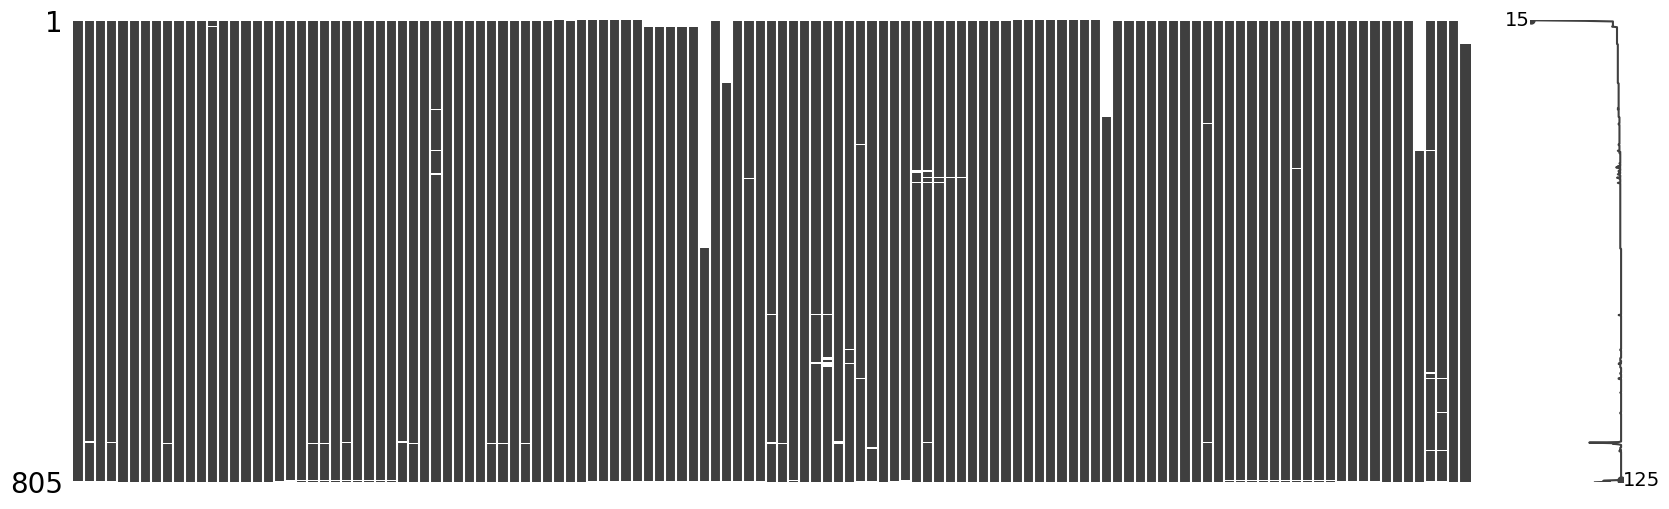

In [3]:
msno.matrix(df, figsize=(20, 6))
#plt.savefig("reports/figures/missing_matrix.png")

#Variables dropped if more than 5% of values are missing
threshold = 0.05
missing_pct = df.isna().mean().sort_values(ascending=False)
print(missing_pct[missing_pct > threshold])

## Correlations

In [4]:
#correlations

corr_matrix = df.corr()
plt.figure(figsize=(120, 100))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')



Text(0.5, 1.0, 'Correlation Matrix')

## Stationariety

In [5]:
raw = pd.read_csv("../data/interim/fredmd_raw.csv", index_col=0, parse_dates=True) 
cleaned = pd.read_csv("../data/interim/fredmd_cleaned.csv", index_col=0, parse_dates=True)

<>:12: SyntaxWarning: invalid escape sequence '\D'
<>:12: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Utente\AppData\Local\Temp\ipykernel_20460\2363127031.py:12: SyntaxWarning: invalid escape sequence '\D'
  plt.title('Personal Consumption Expenditures Price Index Over Time - $\Delta^2 log$')


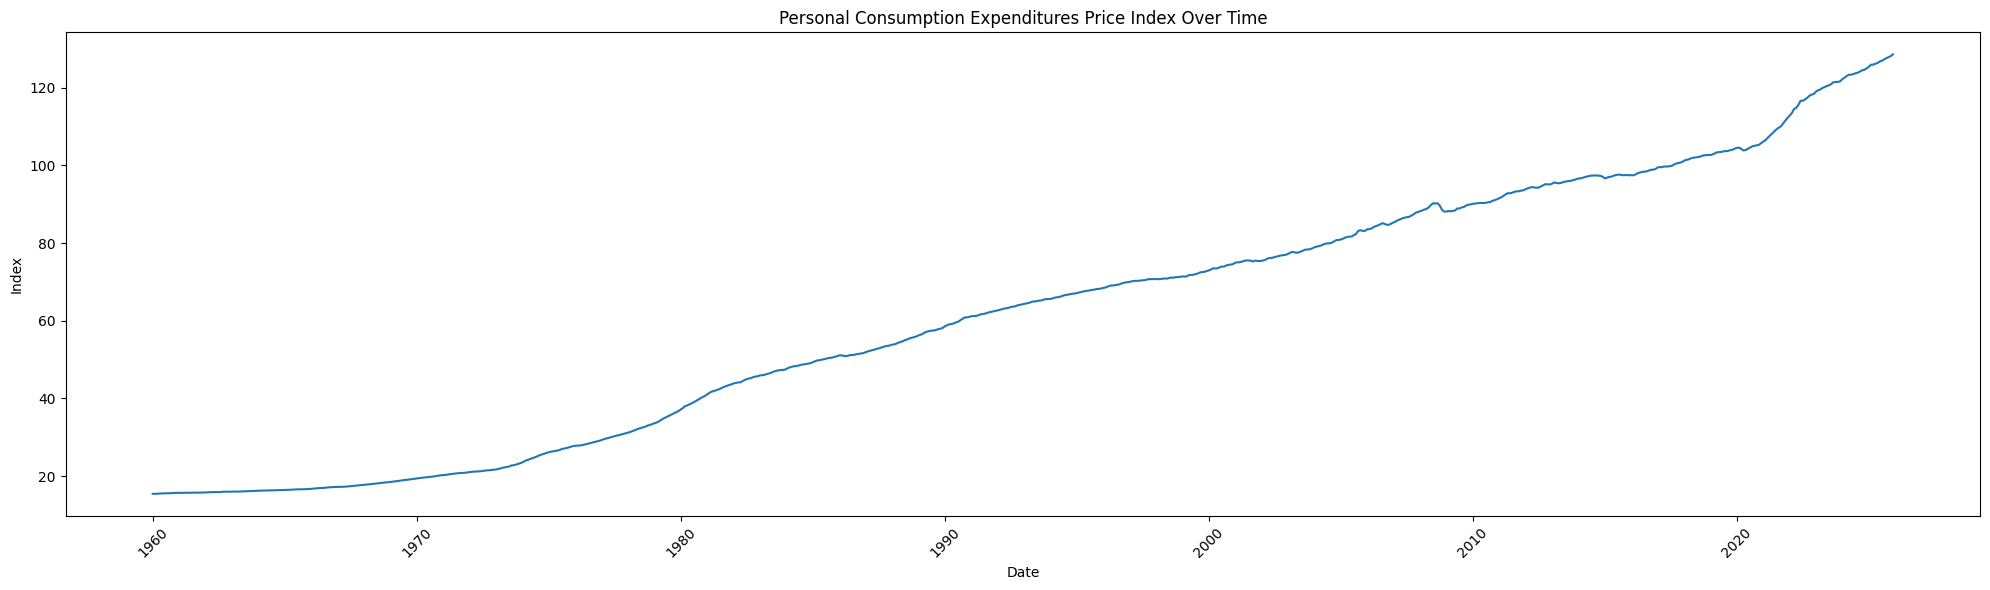

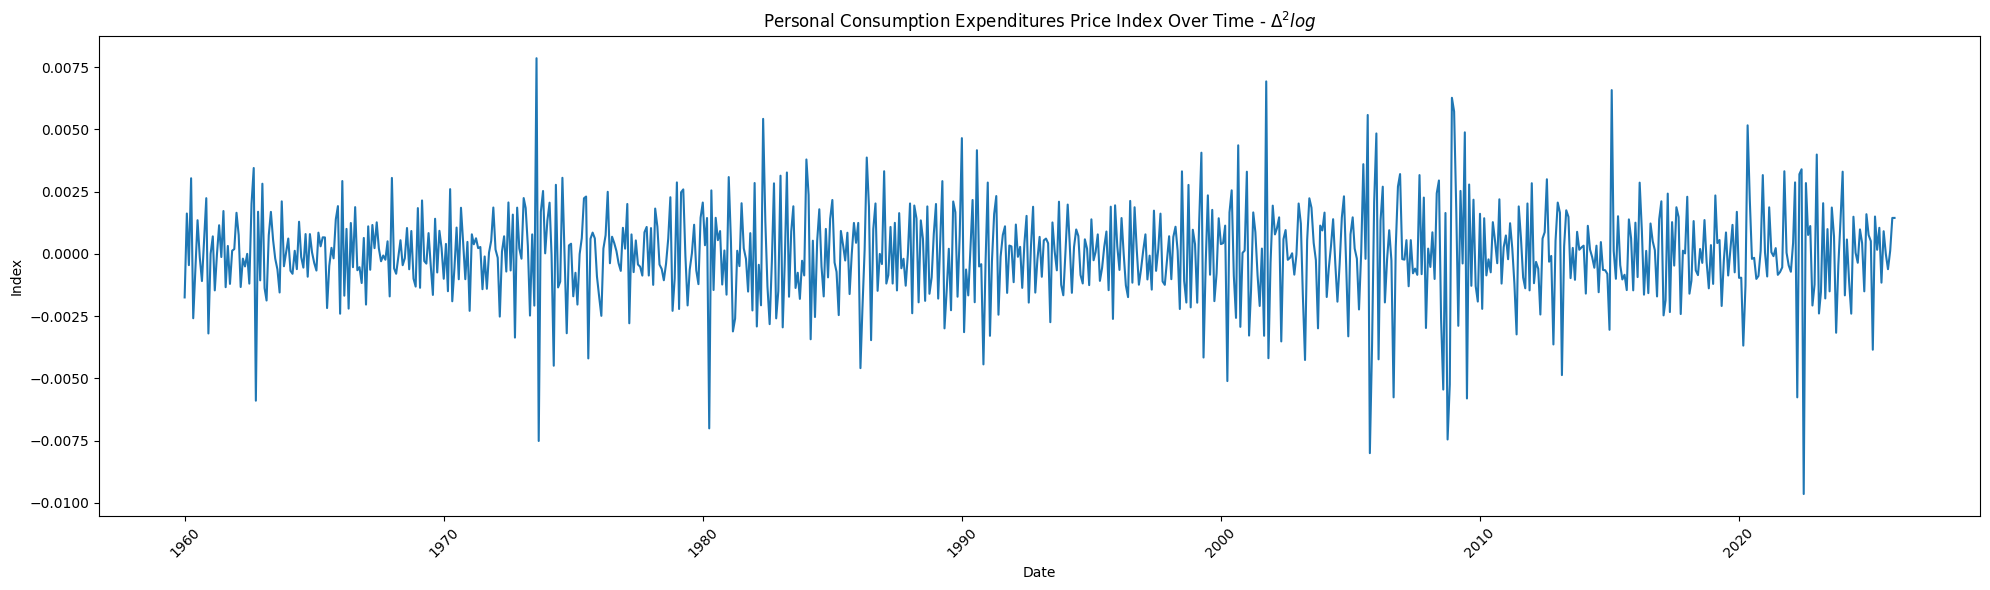

In [6]:
plt.figure(figsize=(20, 6))
plt.plot(raw.loc['1960-01-01':, 'PCEPI'])
plt.title('Personal Consumption Expenditures Price Index Over Time')
plt.xlabel('Date')
plt.ylabel('Index')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 6))
plt.plot(cleaned.loc['1960-01-01':, 'PCEPI'])
plt.title('Personal Consumption Expenditures Price Index Over Time - $\Delta^2 log$')
plt.xlabel('Date')
plt.ylabel('Index')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<>:12: SyntaxWarning: invalid escape sequence '\D'
<>:12: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Utente\AppData\Local\Temp\ipykernel_20460\4022805969.py:12: SyntaxWarning: invalid escape sequence '\D'
  plt.title('Industrial Production Over Time - $\Delta log$')


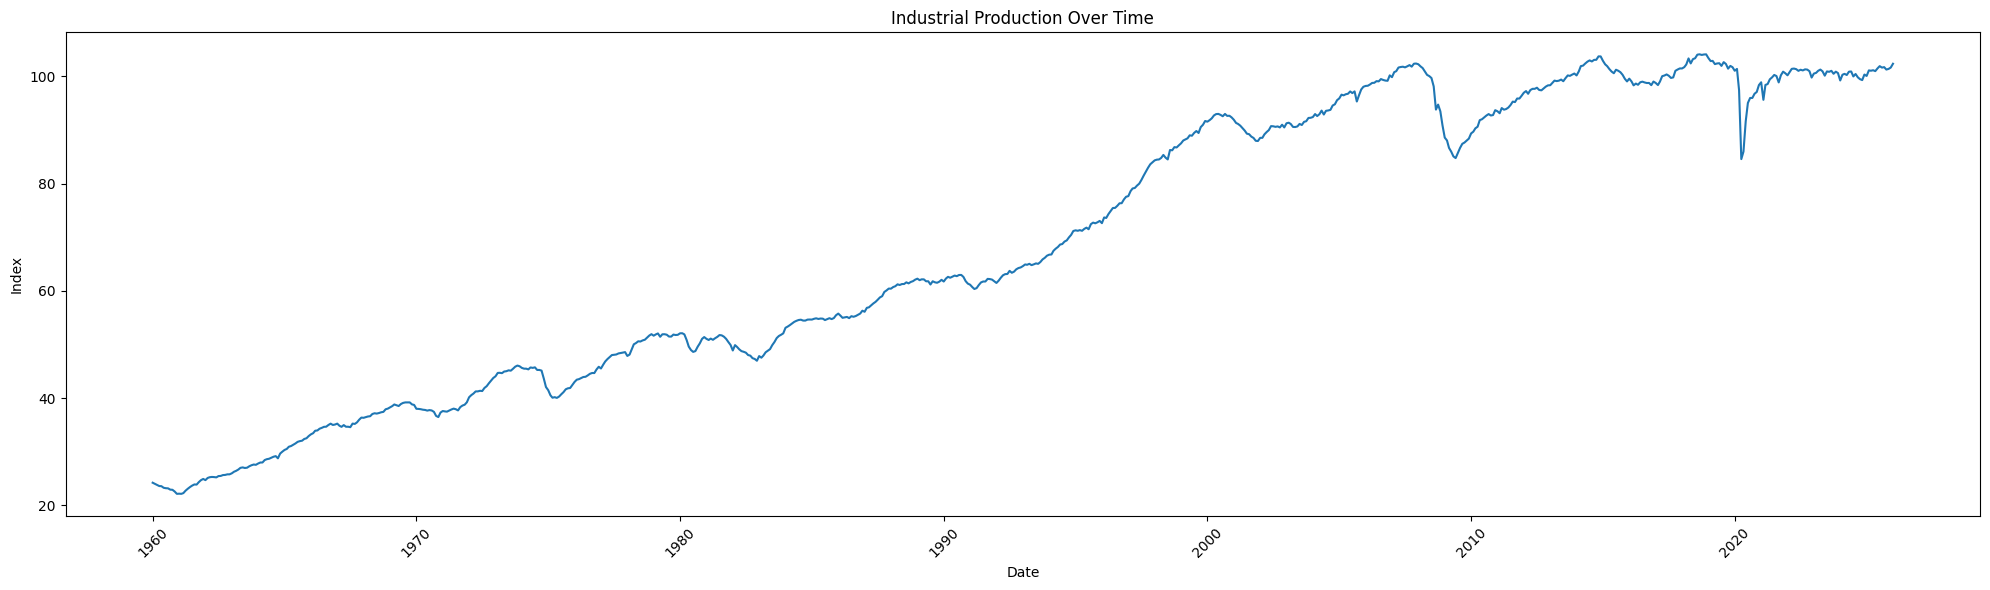

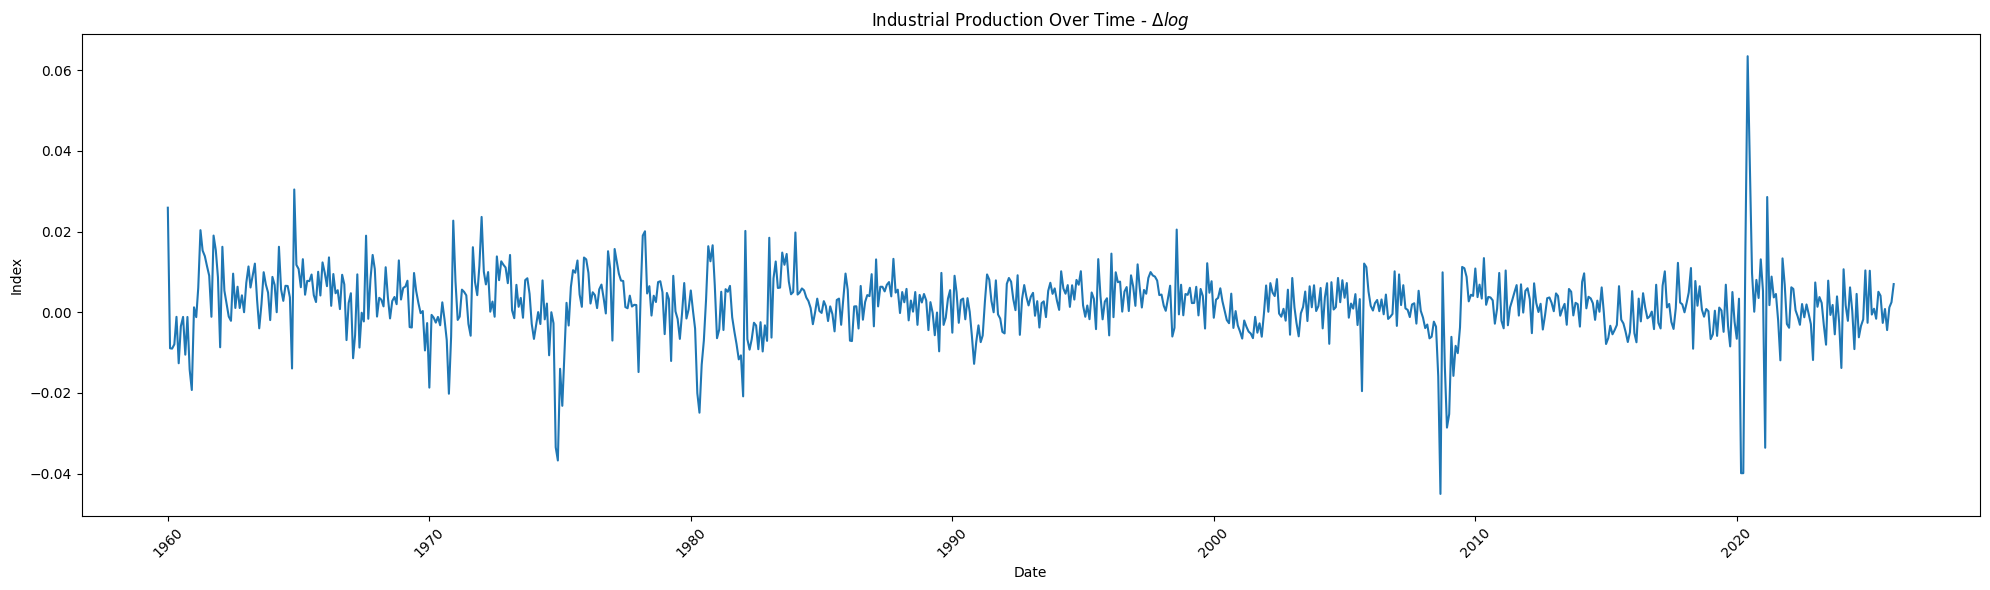

In [7]:
plt.figure(figsize=(20, 6))
plt.plot(raw.loc['1960-01-01':, 'INDPRO'])
plt.title('Industrial Production Over Time')
plt.xlabel('Date')
plt.ylabel('Index')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 6))
plt.plot(cleaned.loc['1960-01-01':, 'INDPRO'])
plt.title('Industrial Production Over Time - $\Delta log$')
plt.xlabel('Date')
plt.ylabel('Index')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
